# LNA design flow
This notebook includes the unified LNA design flow for IHP SG13G2.

<p align="center">
<img src="imag/Cascoded_CG.png" width=500>
</p>

The notebook is divided as follows:
1. Parameter setup
2. Transistor sizing
3. Inductor sizing
4. Ngspice simulation setup
5. Stability analysis

There's still some work to do here:
- Replace ideal current source Iref
- Replace ideal capacitor C_B with MIM capacitor

## Parameter setup
This section declares the necessary parameters for the rest of the flow. Changes made here will affect all other stages.

In [1653]:
FREQUENCY = 10e9    # Operating frequency
VDD    = 1.2   # Operating voltage
C_IN   = 38.98e-15  # Input pad capacitance
C_OUT   = 38.98e-15  # Next stage capacitance

In [1654]:
import os
pdk_root = os.environ.get("PDK_ROOT")
pdk = os.environ.get("PDK")
os.environ["SPICE_SCRIPTS"] = f"{pdk_root}/{pdk}/libs.tech/ngspice"
os.environ["PDK_ROOT"] = pdk_root

## Transistor sizing
The MOSFETs in the LNA are sized following the $g_m/I_D$ strategy using lookup-tables (LUTs). Pre-generated LUTs by Boris Murnmann are available under `lib/gmid_book/starter_files_open_source_tools/ihp-sg13g2/simulation/` for `sg13_lv_nmos`, `sg13_lv_pmos`, `sg13_hv_nmos` and `sg13_hv_pmos`.

Lookup tables were generated in SPICE by sweeping four variables:
* Channel length $L$.
* Gate-Source voltage $V_{GS}$.
* Drain-Source voltage $V_{DS}$.
* Body-Source voltage $V_{SB}$.

The transistor used in the SPICE simulations has 5 gate fingers and a total width $W$ of $10\,\mu \mathrm{m}$.

In [1655]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pygmid import Lookup as lk

# Load the pregenerated lookup file from the submodule
lut = lk('../lib/gmid_book/starter_files_open_source_tools/ihp-sg13g2/simulation/sg13_lv_nmos.mat')

Different channel lengths are available, but following Razavi's advice in his RF Microelectronics book, the shortest available channel is selected.

In [1656]:
# Extract sweeped variables from the LUT
L1 = min(lut['L'])  # 0.13 micron
vgs = lut['VGS']
vds = lut['VDS']
vsb = lut['VSB']

### Sizing $M_1$
In order to correctly size $M_1$ we must first select a bias current $I_{D0}$ that will yield around $80$ to $90\%$ of the saturated value of $g_m$. To better visualize the relationship between $g_m$ and $I_D$ we can plot the curve for the minimum channel length that the technology allows ($0.13\,\mu\mathrm{m}$ for SG13G2):

Max gm: 0.004065
gm_0: 0.003252
Corresponding ID_0: 0.0007301755244755245
gm_0/ID_0: 4.4537236472502535


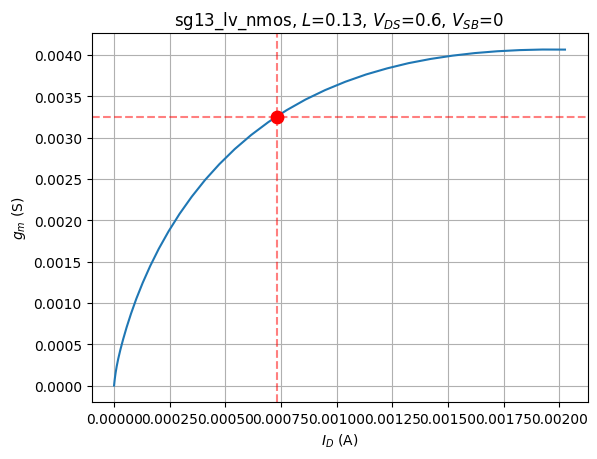

In [1657]:
VDS1=np.max(vds)/2  # Leave sufficient headroom 
VSB1=0      # Body shorted to source

# Get the corresponding rows from the LUT
gm = lut.lookup('GM', L=L1, VDS=VDS1, VSB=VSB1)
Id = lut.lookup('ID', L=L1, VDS=VDS1, VSB=VSB1)

# Select the value that corresponds to 80% of saturated gm
gm_0 = 0.8 * np.max(gm)
ID_0 = np.interp(gm_0, gm, Id)  # Obtain I_D from selected gm
gm_id1 = gm_0 / ID_0

print(f"Max gm: {np.max(gm)}")
print(f"gm_0: {gm_0}")
print(f"Corresponding ID_0: {ID_0}")
print(f"gm_0/ID_0: {gm_id1}")

# Plot gm vs Id, mark selected point
fig, ax1 = plt.subplots()
ax1.grid()
ax1.set_xlabel('$I_{D}$ (A)')
ax1.set_ylabel('$g_m$ (S)')
ax1.plot(Id, gm)
ax1.scatter(ID_0, gm_0, color='r', s=80, zorder=3, label="0.8·gm_max")
ax1.axhline(gm_0, color='r', linestyle='--', alpha=0.5)
ax1.axvline(ID_0, color='r', linestyle='--', alpha=0.5)
plt.title("sg13_lv_nmos"+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()


Note that we've chosen $V_{SB} = 0$ to obtain $I_D$, but $V_{SB}$ depends on $I_D$. Also, the resistance seen at the source depends on the inductor $L_B$ choice, which in turn is selected after sizing $M_1$. Inductor series resistance should be low enough that this is not a problem and $V_S$ can be considered to be $0$ so $V_{SB}=0$ is a good approximation. If inductor resistance is too high, a shunt capacitor can be employed to bring the required inductance down, lowering the length of the conductor and in turn the series resistance.

Now that we have the $g_m/I_D$ ratio for $M_1$, we can obtain the necessary $I_D$ current to achieve $g_m = 1/50\,\Omega$:

In [1658]:
gm1 = 1/ 50
I_D1  = gm1 / gm_id1
print(f"I_D for M1 is {I_D1/1e-3:.3f} mA")

I_D for M1 is 4.491 mA


We can also directly obtain the corresponding width $W$:

In [1659]:
gm_w = lut.look_up('GM_W', GM_ID=gm_id1)
W1 = gm1 / gm_w
print(f"W for M1 is {W1:.3f} microns")

W for M1 is 30.711 microns


If we keep the gate finger width at $2\,\mu\mathrm{m}$ as in the LUT, we can directly obtain the number of gate fingers for $M_1$:

In [1660]:
nf1 = int(np.max([np.round(W1/2), 1]))
print(f"Number of gate fingers for M1 is {nf1}")

Number of gate fingers for M1 is 15


With all geometric parameters chosen, we can now obtain the electrical characteristics of the transistor. We start by visualizing the $V_{GS}$ voltage and transit frequency $f_T$ that correspond to the selected $g_m/I_D$ for $M_1$

VGS_1 = 861.879 mV
f_T1 = 58.490 GHz


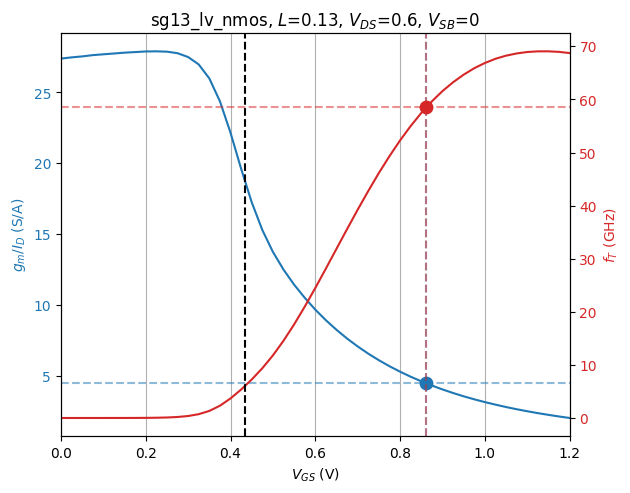

In [1661]:
gm_id = lut.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1)  # Get the gm/ID values from the LUT
V_GS1 = np.interp(gm_id1, np.sort(gm_id), np.flip(vgs))  # Interpolate to obtain V_GS1

ft = lut.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1)/2/np.pi
f_T1 = np.interp(V_GS1, vgs, ft)
print(f"VGS_1 = {V_GS1/1e-3:.3f} mV")
print(f"f_T1 = {f_T1/1e9:.3f} GHz")

vt = lut.lookup('VT', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)

# plot gm/ID and fT versus gate bias
fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(V_GS1, gm_id1, color=color, s=80, zorder=3, label="0.8·gm_max")
ax1.axvline(V_GS1, color=color, linestyle='--', alpha=0.5)
ax1.axhline(gm_id1, color=color, linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft/1e9, color=color)
ax2.scatter(V_GS1, f_T1/1e9, color=color, s=80, zorder=3, label="0.8·gm_max")
ax2.axvline(V_GS1, color=color, linestyle='--', alpha=0.5)
ax2.axhline(f_T1/1e9, color=color, linestyle='--', alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title('sg13_lv_nmos, $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, np.max(vgs))
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

From the graph we can see that the $V_{GS}$ voltage for $M_1$ is around $450\,\mathrm{mV}$ above threshold voltage (black dashed line), and the transit frequency $f_T$ is very close to $60\,\mathrm{GHz}$. Note that $V_{GS}$ varies by $\pm100\dots200\,\mathrm{mV}$ over process and temperature so this graph shouldn't be taken too seriously.

Drain-Source saturation voltage $V_{Dsat}$ is well approximated by $2/(g_m/I_D)$:

In [1662]:
V_Dsat1 = 2 / (gm_id1)
print(f"V_Dsat for M1 is {V_Dsat1/1e-3:.3f} mV")

V_Dsat for M1 is 449.062 mV


Finally, we obtain the capacitances from the LUT

In [1663]:
CGS_W = lut.look_up('CGS_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
CGD_W = lut.look_up('CGD_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
CSS_W = lut.look_up('CSS_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
CDD_W = lut.look_up('CDD_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
C_GS1 = CGS_W * W1
C_SS1 = CSS_W * W1
C_GD1 = CGD_W * W1
C_DD1 = CDD_W * W1
print(f"Gate-Source capacitance for M1 is {C_GS1/1e-15:.3f} fF")
print(f"Source capacitance for M1 is {C_SS1/1e-15:.3f} fF") # css + cjs + cjsol where css = csg + csd + csb
print(f"Gate-Drain capacitance for M1 is {C_GD1/1e-15:.3f} fF")
print(f"Drain capacitance for M1 is {C_DD1/1e-15:.3f} fF")  # cdd + cjd + cjdol where cdd = cdg + cds + cdb

Gate-Source capacitance for M1 is 34.233 fF
Source capacitance for M1 is 41.002 fF
Gate-Drain capacitance for M1 is 19.605 fF
Drain capacitance for M1 is 29.570 fF


*Note: This lookup tables only contain lumped capacitances connected to the gate. The sweep script can be modified to include other capacitances, but this is usually a "good enough" approximation.*

### Sizing $M_B$
The bias of $M_1$ is set by $M_B$ and $I_\mathrm{REF}$. We need to keep $g_m/I_D$ in $M_B$ equal to $g_{m1}/I_{D1}$, but we can set $I_\mathrm{REF} = 0.2 I_{D1}$ to make the bias branch consume just one fifth of the current in the main branch. To ensure correct matching between $M_1$ and $M_B$ this means that
$M_B$ should have one fifth of $M_1$'s gate fingers. This also means that $W_B = 0.2 W_1$.

In [1664]:
I_REF = 0.2 * I_D1
WB = 0.2 * W1
nfB = int(np.max([np.round(WB/2), 1]))

print(f"I_REF = {I_REF/1e-6:.3f} uA")
print(f"WB   = {WB:.3f} micron")
print(f"Number of gate fingers for MB is {nfB}")

I_REF = 898.125 uA
WB   = 6.142 micron
Number of gate fingers for MB is 3


#### Bypass capacitor $C_B$
$C_B$ must offer a very low impedance to ground compared with $R_S$. This capacitor bypasses noise from $M_B$ and $I_\mathrm{REF}$ to ground, preventing gate noise in $M_1$. Note that a low inductance ground is critical for correct operation of $C_B$, because the high frequency performance of this CG state degrades strongly if the impedance seen in series with the gate is comparable to $R_S$.

### Sizing $M_2$
In order to minimize capacitance between $M_1$'s drain and $M_2$'s source, both transistors must be the same width. This allows the drain area of $M_1$ to be shared with the source area of $M_2$ and since this area does not need contacts, it can be minimized. This also eases transistor matching and simplifies the overall design process.

## Inductor sizing
Inductors are sized using the geometric programming approach described in _Optimization of Inductor Circuits via Geometric Programming_ by Hershenon et al.
<p align="center">
<img src="imag/Equiv2.png">
</p>

The inductors must resonate with capacitances seen at $M_1$'s source and $M_2$'s drain.

### Parameter setup

In [1665]:
from gpkit import Variable, Model, ureg

# Design parameters
omega = Variable("\\omega", 2*np.pi*FREQUENCY, "rad/s", "Operating angular frequency",    constant=True)
w_min = Variable("w_{min}", 2e-6      , "m"  , "Minimum TopMetal2 width",      constant=True)
s_min = Variable("s_{min}", 2e-6      , "m"  , "Minimum TopMetal2 separation",   constant=True)
A_max = Variable("A_{max}", (250e-6)**2   , "m^2"  , "Maximum TopMetal2 area",      constant=True)
L_req = Variable("L_{req}", 10       , "nH"   , "Required inductance in nano Henries", constant=True)

# Void characteristics
mu_0  = Variable("\\mu_0", 4*np.pi*1e-7, "H/m", "Magnetic permeability of free space", constant=True)
e_0   = Variable("e_{0}" , 8.854187e-12, "F/m", "Electric permittivity of free space", constant=True)

# Top Metal 2 characteristics
sigma_tm2 = Variable("\\sigma_{tm2}", 30.3e6, "S/m", "Conductivity of TopMetal2 for ihp SG13G2", constant=True)
t_tm2   = Variable("t_{tm2}"   , 3e-6  , "m"  , "Thickness of TopMetal2 for ihp SG13G2"   , constant=True)

# Oxide characteristics
e_ox = 4.1 * e_0
t_ox = Variable("t_{ox}", 6.45e-6 , "m", "Oxide thickness between substrate and TopMetal2", constant=True)

# Via characteristics for Top Metal 2 - Top Metal 1
sigma_tm1tm2 = Variable("\\sigma_{TM1-TM2}", 3.143e6, "S/m", "Conductivity of TopVia2 for ihp SG13G2"    , constant=True)
t_ox_tm1tm2  = Variable("t_{ox,TM1-TM2}"   , 2.8e-6 , "m"  , "Oxide thickness between TopMetal1 and TopMetal2", constant=True)
v_w     = Variable("TV2.a"     , 0.9e-6 , "m"  , "TopVia1 width"              , constant=True)
v_s     = Variable("TV2.b"     , 1.06e-6, "m"  , "TopVia1 width"              , constant=True)
v_e     = Variable("TV2.c"     , 0.5e-6 , "m"  , "TopVia1 width"              , constant=True)

# Substrate characteristics
e_sub   = 11.9 * e_0
t_sub   = Variable("t_{sub}"   , 180e-6, "m"  , "Substrate thickness for 200um back lapping option", constant=True)
sigma_sub = Variable("\\sigma_{sub}", 2   , "S/m", "Conductivity of substrate for ihp SG13G2"    , constant=True)

### Design variables
We start by defining the basic design variables:

In [1666]:
w   = Variable("w"   , "m", "Metal track width"       , positive=True)
s   = Variable("s"   , "m", "Spacing between metal tracks"  , positive=True)
n   = Variable("n"   , "-", "Number of turns"       , positive=True)
d_out = Variable("d_{out}", "m", "Outter diameter of the inductor" , positive=True)
d_avg = Variable("d_{avg}", "m", "Average diameter of the inductor", positive=True)

Other design variables are derived from this five basic ones.

#### Series inductance
This is the main design variable and can be approximated by the monomial expression
$$
L_s = \beta d_\mathrm{out}^{\alpha_1}w^{\alpha_2}d_\mathrm{avg}^{\alpha_3}n^{\alpha_4}s^{\alpha_5},
$$
where $\beta$ and $\alpha_{1-5}$ are geometry dependent coefficients. The following expression is valid for octagonal spirals

In [1667]:
beta  =  1.330e-3
alpha_1 = -1.210
alpha_2 = -0.163
alpha_3 =  2.430
alpha_4 =  1.750
alpha_5 = -0.049

# Auxiliar variables to fix gpkit and pint unit mismatch
um = Variable("um", 1e-6, "m", constant=True)

L = beta * (d_out/um)**alpha_1 * (w/um)**alpha_2 * (d_avg/um)**alpha_3 * n**alpha_4 * (s/um)**alpha_5 \
   * Variable("nH", 1e-9, "H", constant=True)

#### Series resistance
Series resistance is composed by metal resistance and via resistance
$$
R_s = R_m + R_v
$$

The expression for metal resistance is given by
$$
R_m = \frac{l}{\sigma w\delta(1 - e^{-t/\delta})} = k_1 \frac{l}{w},
$$
where $\delta$ is the skin depth of Top Metal 1 at operating frequency and $t$ is the metal thickness.

In [1668]:
skin_depth_tm1 = np.sqrt(2/(omega * mu_0 * sigma_tm2).value)
l = 8 * d_avg * n / (1 + 2**0.5) # Conductor length (8 sides of an octagon with a span of d_avg)

if (skin_depth_tm1 < t_tm2.value):
  print(f"Skin depth is {skin_depth_tm1.to("um"):.3f}")
  k_1 = 1 / (sigma_tm2 * skin_depth_tm1*(1 - np.exp(-t_tm2.value/skin_depth_tm1)))
else:
  print("No skin effect")
  k_1 = 1 / (sigma_tm2 * t_tm2)  # No skin effect occurs

R_m  = k_1 * l / w

Skin depth is 0.914 micrometer


Via resistance is given by
$$
R_v = \frac{t_{tm1,tm2}}{\sigma v_w \delta(1 - e^{-v_w/\delta})} \times 2n \left(\frac{w}{v_w + v_s}\right)^{-2} = k_2 \frac{n}{w^2},
$$
where $v_w$ and $v_s$ are via width and spacing respectivelly. Note that the last term has a negative exponent because vias in a single via set are in parallel, but the $2n$ term has a positive exponent because successive via sets are in series with each other. This formula assumes vias are grouped in a square set and that each underpass has 2 via sets. Also it includes the approximations $n \approx n-1$ and $v_s \approx 2v_e$, where $v_e$ is the via enclosure. This approximation is valid for Top Metal 2 where $v_s = 1.06\,\mu\mathrm{m}$ and $v_e = 0.5\,\mu\mathrm{m}$, but may need adjustments if other layers are used. 

In [1669]:
skin_depth_via = np.sqrt(2/(omega * mu_0 * sigma_tm1tm2).value)
if (skin_depth_via < v_w.value):
  print(f"Skin depth in via is {skin_depth_via.to("um"):.3f}")
  k_2 = 2 *t_ox_tm1tm2.value / (sigma_tm1tm2 * v_w * skin_depth_via*(1 - np.exp(-v_w/skin_depth_via)) * (v_w + v_s)**2).value
else:
  print("No skin effect in via")
  k_2 = 2 * t_ox_tm1tm2.value * (v_w + v_s).value**2 / (sigma_tm1tm2 * v_w * v_w).value

# Auxiliar variables to fix gpkit and pint unit mismatch
m = Variable("m"  , 1, "m"  , constant=True)
o = Variable("ohm", 1, "ohm", constant=True)

R_v = k_2.to("ohm*m^2").magnitude * n * (w/m)**-2 * o 

No skin effect in via


Because directly summing $R_s$ and $R_v$ will result in a posynomial, we define an auxiliary variable for $R_s$:

In [1670]:
R_s = Variable("R_{s}", "ohm", positive=True)

When building the constraints we can specify $R_s \geq R_m + R_v$ and because higher $R_s$ hurts the quality factor, this expression is pushed towards equality.

#### Oxide capacitance
Inductor current is capacitively coupled to the substrate through the oxide layers. Spiral-substrate oxide capacitance can be approximated by
$$
C_\mathrm{ox} = \frac{\epsilon_\mathrm{ox}lw}{2t_\mathrm{ox}} = k_3 lw
$$

In [1671]:
k_3 = (e_ox )/(2 * t_ox)
C_ox = k_3 * l * w

#### Series capacitance
Series capacitance is mainly due to the capacitance between the main spiral and metal underpasses. Since in octagonal spirals each underpass means one $w^2$ overlap, the expression for series capacitance is
$$
C_s = \frac{\epsilon_\mathrm{ox} (n-1)w^2}{t_{\mathrm{ox},tm1-tm2}} \approx \frac{\epsilon_\mathrm{ox} nw^2}{t_{\mathrm{ox},tm1-tm2}} = k_4nw^2
$$

In [1672]:
k_4 = (e_ox)/(t_ox_tm1tm2)
C_s = k_4 * n * w**2

#### Substrate capacitance
Substrate capacitance is given by the monomial expression
$$
C_\mathrm{sub} = \frac{\epsilon_\mathrm{sub}}{2t_\mathrm{sub}} = k_5 lw
$$
Note that the $1/2$ factor comes from the fact that in the equivalent model this capacitance is split into two parallel capacitors.

In [1673]:
k_5 = e_sub / (2 * t_sub)
C_sub = k_5 * l * w

#### Substrate resistance
For substrate resistance we will consider that the return current tightly follows the spiral path, so it can be expressed by
$$
R_\mathrm{sub} = \frac{2t_\mathrm{sub}}{\sigma_\mathrm{sub}lw} = \frac{k_6}{lw}
$$

In [1674]:
k_6 = 2 * t_sub / sigma_sub

# Fix gpkit and pint unit mismatch
ohm_m2   = Variable("ohm_m2", 1, "ohm*m^2", constant=True)
k_6 = k_6.to('ohm*m^2').value.magnitude * ohm_m2

R_sub = k_6 / (l * w)

### One port equivalent model and Q factor
When one of the inductor terminals is grounded, we can express the total shunt resistance to ground as
$$
R_p = \frac{1 + [\omega R_\mathrm{sub} (C_\mathrm{sub} + C_\mathrm{ox}) ]^2}{\omega^2R_\mathrm{sub}C_\mathrm{ox}^2}.
$$
Note that $R_p$ does not include series resistance $R_s$.

If we substitute capacitance and resistance by their corresponding monomial expressions, we find
$$
R_p = \frac{k_6^2\omega^2(k_3+k_5)^2+1}{k_3^2k_6\omega^2lw} = \frac{k_7}{lw},
$$
where
$$
k_7=
\frac{k_{6} \left(k_{3} + k_{5}\right)^{2}}{k_{3}^{2}} + \frac{1}{k_{3}^{2} k_{6} \omega^{2}}
$$

In [1675]:
k_7 = k_6 * (k_3 + k_5)** 2 / (k_3**2) + 1/ (k_3**2 * k_6 * omega**2)

# Fix gpkit and pint unit mismatch
k_7 = k_7.to('ohm*m^2').value.magnitude * ohm_m2

R_p = k_7 / (l* w)

Also, total shunt capacitance can be expressed as the following polynomial
$$
C_p = \frac{C_\mathrm{ox}+\omega^2R_\mathrm{sub}^2(C_\mathrm{sub} + C_\mathrm{ox})C_\mathrm{sub}C_\mathrm{ox}}{1 + [\omega R_\mathrm{sub}(C_\mathrm{sub} + C_\mathrm{ox})]^2}
$$
_Note: The original formula from the paper contains an error: the $R_\mathrm{sub}$ term in the numerator should be squared (as it is here)._

If we substitute capacitance and resistance by their corresponding monomial expressions, we arrive at
$$
C_p = \frac{k_3 lw \left(k_5k_6^2\omega^2(k_3+k_5) + 1\right)}{k_6^2\omega^2(k_3 + k_5)^2 + 1} = k_8 lw,
$$
where
$$ 
k_8= \frac{k_{3} \left(k_{3} k_{5} k_{6}^{2} \omega^{2} + k_{5}^{2} k_{6}^{2} \omega^{2} + 1\right)}{k_{3}^{2} k_{6}^{2} \omega^{2} + 2 k_{3} k_{5} k_{6}^{2} \omega^{2} + k_{5}^{2} k_{6}^{2} \omega^{2} + 1}
$$

In [1676]:
num = k_3 * (k_3 * k_5 * k_6**2 * omega**2 + (k_5 * k_6 * omega)**2 + 1)
den = (k_3 * k_6 * omega)**2  + 2 * k_3 * k_5 * k_6**2 * omega**2 + k_5**2 * k_6**2 * omega**2 + 1
k_8 = num.value / den.value

# Fix gpkit and pint unit mismatch
F_per_m2 = Variable("F_per_m2", 1, "F/m^2", constant=True)
k_8 = k_8.to('F/m^2').magnitude * F_per_m2

C_p = k_8 * l * w

For the quality factor of the inductor $Q_L$, we know
$$
Q_L = \frac{\mathrm{Im}(Z)}{\mathrm{Re}(Z)} = -\frac{\mathrm{Im}(Y)}{\mathrm{Re}(Y)},
$$
and taking the admitance of the one-port equivalent model yields
$$
\mathrm{Im}(Y) = \omega (C_s + C_p) - \frac{\omega L_s}{\omega^2 L_s^2 + R_s^2}
$$
$$
\mathrm{Re}(Y) = \frac{R_s}{\omega L_s^2+ R_s^2} + \frac{1}{R_p}.
$$
We define $C_\mathrm{tot} = C_s + C_p$ and arrive at the following expression for the $Q$ factor
$$
Q_L = \frac{\omega L_{s}}{R_s}\cdot\frac{ R_p  \left(1  - \frac{R_s^2C_\mathrm{tot}}{L_s} - \omega^{2}L_{s}C_\mathrm{tot} \right)}{R_p+\left[\left(\frac{L_{s} \omega}{R_s}\right)^{2} +1\right]R_{s}}c.
$$
Because this expression is not a posynomial, we can't use it directly in the geometric programming model, but the constraint $Q \geq Q_\mathrm{min}$ can be written as
$$
\frac{Q_\mathrm{min} R_s}{\omega L_s R_p} \left[R_p + \frac{(\omega L_s)^2}{R_s} + R_s \right] + \frac{R_s^2C_\mathrm{tot}}{L_s} + \omega^2 L_s C_\mathrm{tot} \leq 1,
$$
which allows us to either specify a minimum required quality factor or maximizing $Q_L$ by maximizing $Q_\mathrm{min}$.

We won't be concerned with the inductors quality factor in this case because the whole $LC$ tank can be optimized in a single model, but a minimum $Q_L$ could be specified in the constraints if necessary.

### Sizing the inductor for an $LC$ tank
Since we have all the necessary expressions for sizing an inductor, we can use them to design an $LC$ tank at any resonance frequency. For this, note that we can reorganize the one-port equivalent circuit to be an $RLC$ parallel circuit with no series branches by obtaining the parallel equivalent for $L_s$ and $R_s$
$$
L_{s,p} = \left[1 + \left(\frac{R_s}{L_s\omega}\right)^2\right]L_s,
$$
$$
R_{s,p} = \left[1 + \left(\frac{L_s\omega}{R_s}\right)^2\right]R_s.
$$
This way we obtain a resonance tank with values
$$
L_\mathrm{tank} = L_{s,p},
$$
$$
R_\mathrm{tank} = R_p || R_{s,p},
$$
$$
C_\mathrm{tank} = C_\mathrm{tot} + C_L,
$$
where $C_L$ is the load capacitance. Note that $R_\mathrm{tank}$ is not a posynomial, but whenever $Q_\mathrm{tank}=R_\mathrm{tank}/(\omega L_\mathrm{tank}) > 1.5$, $R_{s,p}$ can be approximated by a monomial
$$
R_{s,p} \approx \frac{(L_s\omega)^2}{R_s}.
$$

In [1677]:
L_tank   = (1 + (R_s / (L * omega))**2) * L
inv_R_tank = R_s/(L * omega)**2 + 1 / R_p

Because both $L_\mathrm{tank}$ and the inverse of $R_\mathrm{tank}$ are posynomial functions of design variables, the inverse of $Q_\mathrm{tank}$ is also a posynomial and can therefore be maximized or constrained to be above a minimum value.

In [1678]:
Q_tankmin = Variable("Q_{tankmin}", 1.4, "-", "Minimum tank quality factor", constant=True)

#### Load capacitance
For the LNA we must design two different $LC$ tanks: one for the source of $M_1$ and one for the drain of $M_2$. This means that the load capacitance for each inductor is different. For the input tank, the load capacitance comes from the input pad, and $C_{ss}$ for $M_1$ and for the output tank it comes from the next stage's capacitance and $C_{dd}$ for $M_1$. In the following code $C_{L2}$ indicates the input tank's load and $C_{L1}$ the load for the output tank to keep indices as close as possible to the schematic at the start of this notebook.

In [1679]:
C_L2 = Variable("C_{L2}", C_IN  + C_SS1, "F", "Input tank load capacitance", constant=True, positive=True)
C_L1 = Variable("C_{L1}", C_OUT + C_DD1, "F", "Input tank load capacitance", constant=True, positive=True)
print(f"C_L2 is {C_L2.value.to("fF"):.3f}")
print(f"C_L1 is {C_L1.value.to("fF"):.3f}")

C_tank = C_L2 + C_p + C_s

C_L2 is 79.982 femtofarad
C_L1 is 68.550 femtofarad


### Constraints
Now that we have our design variables declared, we can start building the constraints for the model.

The first constraint is that the tank's resonance frequency must be the operating frequency. Since this is a geometric programming model, we must declare it as an inequality
$$
L_\mathrm{tank} C_\mathrm{tank} \leq \frac{1}{\omega^2}
$$

In [1680]:
constraints = [L_tank * C_tank <= omega**(-2)]

We must also impose a minimum tank quality factor so that the $R_{s,p}$ approximation holds
$$
Q_\mathrm{tank} \geq Q_\mathrm{tank, min}
$$

In [1681]:
constraints += [omega * L_tank * inv_R_tank <= 1/Q_tankmin]

Because the series resistance $R_s$ was implemented as a variable instead of a sum, we add the constraint that makes $R_s = R_m + R_v$

In [1682]:
constraints += [R_s >= R_m + R_v]

The PDK imposes dimensional constraints on the traces of Top Metal 1 and Top Metal 2, so we must add them to the model

In [1683]:
constraints += [w >= w_min,
      s >= s_min]

Finally, we must ensure that the resulting geometry is feasible. For this, we need to impose the constraint
$$
d_\mathrm{avg} + (n-1)s + nw = d_\mathrm{out}.
$$
To convert this expression into a geometric programming compatible form, we first approximate $n-1\approx n$ and then we change the equality into an inequality

In [1684]:
constraints += [d_avg + n*s + n*w <= d_out]

#### Objective Function
The objective function for the resonance tanks in this case is to maximize the tanks resistance. This is because at resonance, the impedance seen by the transistors is given by $R_\mathrm{tank}$. If it was an ideal resonance tank, then $R_\mathrm{tank} = \infty$, so we know we need to maximize.

In [1685]:
objective = inv_R_tank  # gpkit minimizes, so we pass the inverse of R_tank as the objective

#### Helper functions
For easier printing of the solutions, some helper functions are defined here.

In [1686]:
def sol_value(solution, var):
  return var.sub(solution["variables"]).value

def print_solution(solution):
  print(f"""=== [Inductor dimensions] ===
w={sol_value(solution, w).to("um"):.3f}\ns={sol_value(solution, s).to("um"):.3f}\nl={sol_value(solution, l).to("um"):.3f}
n={sol_value(solution, n):.3f} turns
d_out={sol_value(solution, d_out).to("um"):.3f}\nd_avg={sol_value(solution, d_avg).to("um"):.3f}
d_in={(sol_value(solution, d_avg) - (sol_value(solution, n)-1)*sol_value(solution, s) - sol_value(solution, n * w)).to("um"):.3f}
=== [Inductor values] ===
C_p={sol_value(solution, C_p).to("fF"):.3f}\nC_sub={sol_value(solution, C_sub).to("fF"):.3f}\nC_ox={sol_value(solution, C_ox).to("fF"):.3f}
C_s={sol_value(solution, C_s).to("fF"):.3f}
R_sub={sol_value(solution, R_sub).to("kohm"):.3f}
R_s={sol_value(solution, R_s).to("ohm"):.3f}\nR_m={sol_value(solution, R_m).to("ohm"):.3f}\nR_v={sol_value(solution, R_v).to("ohm"):.3f}
R_p={sol_value(solution, R_p).to("kohm"):.3f}
L={sol_value(solution, L).to("nH"):.3f}
=== [ Tank values] ===
L_tank={sol_value(solution, L_tank).to("nH"):.3f}
C_tank={sol_value(solution, C_tank).to("fF"):.3f}
R_tank={(1/sol_value(solution, inv_R_tank)).to("kohm"):.3f}
Q_tank={1/sol_value(solution, omega * L_tank * inv_R_tank):.3f}
f_tank={(1/(2*np.pi*np.sqrt(sol_value(solution, L_tank * C_tank)))).to("GHz"):.3f}""")

### Input tank
We start by sizing the input tank.

In [1687]:
C_tank = C_L2 + C_p + C_s

input_tank = Model(objective, constraints)
sol_in = input_tank.solve()
print_solution(sol_in)

Using solver 'cvxopt'
 for 6 free variables
  in 7 posynomial inequalities.
Solving took 0.00886 seconds.
=== [Inductor dimensions] ===
w=11.674 micrometer
s=2.000 micrometer
l=1872.802 micrometer
n=3.062 turns
d_out=226.467 micrometer
d_avg=184.602 micrometer
d_in=144.737 micrometer
=== [Inductor values] ===
C_p=5.841 femtofarad
C_sub=6.399 femtofarad
C_ox=61.528 femtofarad
C_s=5.410 femtofarad
R_sub=8.233 kiloohm
R_s=6.206 ohm
R_m=6.017 ohm
R_v=0.190 ohm
R_p=10.042 kiloohm
L=2.773 nanohenry
=== [ Tank values] ===
L_tank=2.776 nanohenry
C_tank=91.233 femtofarad
R_tank=3.289 kiloohm
Q_tank=18.854
f_tank=10.000 gigahertz


#### Output tank
Now we can size the output tank

In [1688]:
# Replace the resonance constraint
C_tank = C_L1 + C_p + C_s
constraints[0] = [L_tank * C_tank <= omega**(-2)]

output_tank = Model(objective, constraints)
sol_out = output_tank.solve()
print_solution(sol_out)

Using solver 'cvxopt'
 for 6 free variables
  in 7 posynomial inequalities.
Solving took 0.0178 seconds.
=== [Inductor dimensions] ===
w=10.159 micrometer
s=2.000 micrometer
l=1999.500 micrometer
n=3.345 turns
d_out=221.053 micrometer
d_avg=180.377 micrometer
d_in=141.701 micrometer
=== [Inductor values] ===
C_p=5.427 femtofarad
C_sub=5.945 femtofarad
C_ox=57.165 femtofarad
C_s=4.476 femtofarad
R_sub=8.861 kiloohm
R_s=7.655 ohm
R_m=7.382 ohm
R_v=0.274 ohm
R_p=10.809 kiloohm
L=3.224 nanohenry
=== [ Tank values] ===
L_tank=3.229 nanohenry
C_tank=78.454 femtofarad
R_tank=3.583 kiloohm
Q_tank=17.664
f_tank=10.000 gigahertz


## Ngspice simulation

Using ngspice, we can simulate the circuit to characterize it

In [1689]:
circ_title = f".title LNA {FREQUENCY/1e9} GHz"
## Include SG13G2 library models
lib_includes = f"""
.lib {pdk_root}/{pdk}/libs.tech/ngspice/models/cornerMOSlv.lib mos_tt
.lib {pdk_root}/{pdk}/libs.tech/ngspice/models/cornerMOShv.lib mos_tt
.lib {pdk_root}/{pdk}/libs.tech/ngspice/models/cornerHBT.lib hbt_typ
.lib {pdk_root}/{pdk}/libs.tech/ngspice/models/cornerRES.lib res_typ
.lib {pdk_root}/{pdk}/libs.tech/ngspice/models/cornerCAP.lib cap_typ
"""

We can build the netlist using the obtained values from the geometric programming model and the gm/Id transistor sizing strategy:

In [1690]:
netlist = f"""
** VDD source
VDD VDD 0 {VDD}
** Bias branch
IREF VDD G1 {I_REF/1e-6:.3f}u
CB G1 0 1p
XMB G1 G1 0 0 sg13_lv_nmos w={WB:.3f}u l={L1:.3f}u ng={nfB} m=1 rfmode=1
** Input source and capacitance
Vin VIN 0 DC 0 AC 1
R0 VIN S1 50
Cpad S1 0 {C_IN/1e-15}f
** Input resonance tank
Rp2 S1 0 {sol_value(sol_in, R_p).to("kohm").magnitude:.3f}k
Ls2 S1 net1 {sol_value(sol_in, L).to("nH").magnitude:.3f}n
Rs2 net1 0 {sol_value(sol_in, R_s).to("ohm").magnitude:.3f}
Ctot2 S1 0 {sol_value(sol_in, C_p + C_s).to("fF").magnitude:.3f}f
** Cascoded CG amplifier
XM1 X G1 S1 0 sg13_lv_nmos w={W1:.3f}u l={L1:.3f}u ng={nf1} m=1 rfmode=1
XM2 VOUT VDD X 0 sg13_lv_nmos w={W1:.3f}u l={L1:.3f}u ng={nf1} m=1 rfmode=1
** Output resonance tank
Rp1 VDD VOUT {sol_value(sol_out, R_p).to("kohm").magnitude:.3f}k
Ls1 VDD net2 {sol_value(sol_out, L).to("nH").magnitude:.3f}n
Rs1 net2 VOUT {sol_value(sol_out, R_s).to("ohm").magnitude:.3f}
Ctot1 VDD VOUT {sol_value(sol_out, C_p + C_s).to("fF").magnitude:.3f}f
** Output capacitance
Cpad2 VOUT 0 {C_OUT/1e-15}f
"""

We will perform AC and noise analysis over this circuit:

In [1691]:
control_block = f"""
.control
save all
* --- AC analysis ---
ac dec 100 100e6 100e9
write .out/CG_LNA_{FREQUENCY/1e9}GHz.raw
set appendwrite
* --- Noise ---
set sqrnoise
noise v(VOUT) Vin dec 100 100e6 20e9
setplot noise1
display
write .out/CG_LNA_{FREQUENCY/1e9}GHz.raw
.endc
"""

In [1692]:
# Write the SPICE file
with open(f".out/CG_LNA_{FREQUENCY/1e9}GHz.spice", "w") as f:
  f.write(circ_title)
  f.write(lib_includes)
  f.write(netlist)
  f.write(control_block)
# Run the simulation
freq = str(FREQUENCY/1e9)
!ngspice -b {'.out/CG_LNA_' + freq + 'GHz.spice'} >> /dev/null

Note: Starting dynamic gmin stepping
Note: Dynamic gmin stepping completed
Note: Starting dynamic gmin stepping
Note: Dynamic gmin stepping completed


In [1693]:
def parse_ngspice_raw(filename):
  """Return a list of analysis dicts from a (possibly multi-analysis) .raw file.

  Each dict has keys:
   name   - title string
   plotname  - e.g. 'AC Analysis', 'Noise Spectral Densities', …
   flags   - list of flag strings (e.g. ['complex'])
   variables - list of {index, name, type} dicts
   data   - {var_name: ndarray}  (complex for AC/SP, real for noise)
  """
  with open(filename, "rb") as f:
   content = f.read()

  analyses, pos = [], 0

  while pos < len(content):
   marker = b"Binary:\n"
   header_end = content.find(marker, pos)
   if header_end == -1:
     break

   header_text = content[pos:header_end].decode("latin-1")
   data_start  = header_end + len(marker)

   # ---- parse ASCII header ----
   analysis  = {"name": "", "plotname": "", "flags": [],
         "variables": [], "data": {}}
   num_vars, num_points = 0, 0
   in_vars = False

   for line in header_text.split("\n"):
     line = line.rstrip()
     if not line:
      in_vars = False
      continue
     if line.startswith("Title:"):
      analysis["name"] = line[6:].strip()
     elif line.startswith("Plotname:"):
      analysis["plotname"] = line[9:].strip()
     elif line.startswith("Flags:"):
      analysis["flags"] = line[6:].strip().split()
     elif line.startswith("No. Variables:"):
      num_vars = int(line.split(":", 1)[1].strip())
     elif line.startswith("No. Points:"):
      num_points = int(line.split(":", 1)[1].strip())
     elif line.startswith("Variables:"):
      in_vars = True
     elif in_vars and line and line[0] in "0123456789\t ":
      parts = line.split()
      if len(parts) >= 3:
        analysis["variables"].append(
         {"index": int(parts[0]), "name": parts[1], "type": parts[2]}
        )

   # ---- read binary block ----
   is_complex = "complex" in analysis["flags"]
   vals_per_point = num_vars * (2 if is_complex else 1)
   data_size = num_points * vals_per_point * 8  # 8 bytes per double

   raw = content[data_start: data_start + data_size]
   flat = np.frombuffer(raw, dtype="<f8")     # little-endian float64

   if is_complex:
     arr = flat.reshape(num_points, num_vars, 2)
     for i, var in enumerate(analysis["variables"]):
      analysis["data"][var["name"]] = arr[:, i, 0] + 1j * arr[:, i, 1]
   else:
     arr = flat.reshape(num_points, num_vars)
     for i, var in enumerate(analysis["variables"]):
      analysis["data"][var["name"]] = arr[:, i]

   analyses.append(analysis)
   pos = data_start + data_size

  return analyses

def get_s(data, a, b):
      for key in [f"s_{a}_{b}", f"s({a},{b})", f"s{a}{b}"]:
         if key in data:
            return data[key]
      raise KeyError(f"Cannot find S{a}{b} in raw file keys: {list(data.keys())}")


In [1694]:
analyses = parse_ngspice_raw(f'.out/CG_LNA_{FREQUENCY/1e9}GHz.raw')
ac_data   = None   # AC sweep
noise_data = None   # Noise spectral densities
for a in analyses:
   pn = a["plotname"].lower()
   if "ac analysis" in pn:
      ac_data = a
   elif "noise" in pn:
      noise_data = a

print(f"Found {len(analyses)} analysis block(s):")
for a in analyses:
   print(f"  plotname='{a['plotname']}',  "
        f"vars={len(a['variables'])},  "
        f"points={len(next(iter(a['data'].values())))}")

Found 2 analysis block(s):
  plotname='AC Analysis',  vars=142,  points=301
  plotname='Noise Spectral Density Curves - (V^2 or A^2)/Hz',  vars=3,  points=231


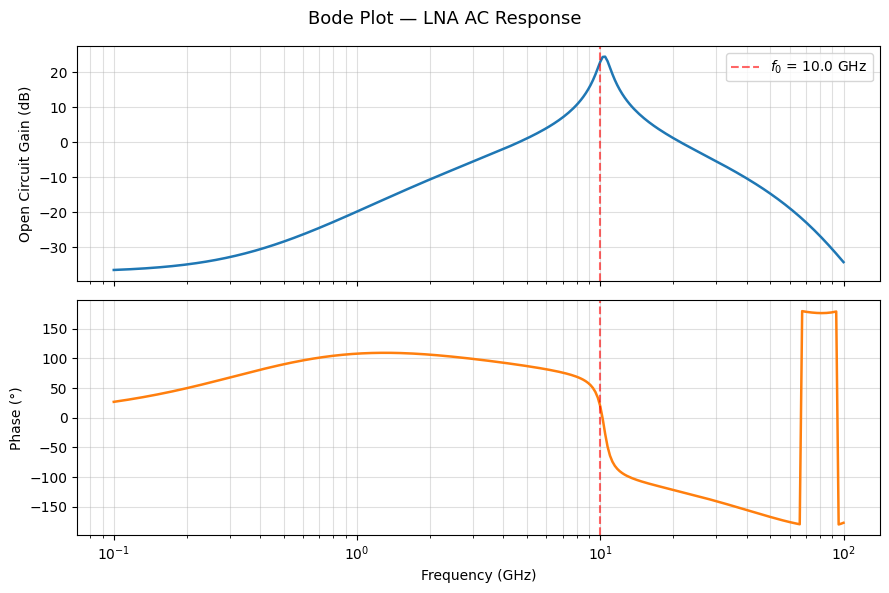

Peak gain : 24.41 dB  @ 10.471 GHz
Gain @ f0 : 22.95 dB


In [1695]:
freq_ac  = np.abs(ac_data["data"]["frequency"])   # Hz
v_out    = ac_data["data"]["v(vout)"]
v_in     = ac_data["data"]["v(vin)"]           # = V_source (voltage divider handled below)

gain_dB   = 20 * np.log10(np.abs(v_out/v_in))
phase_deg = np.angle(v_out/v_in, deg=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle("Bode Plot — LNA AC Response", fontsize=13)

# --- magnitude ---
ax1.semilogx(freq_ac / 1e9, gain_dB, "C0", linewidth=1.8)
ax1.axvline(FREQUENCY / 1e9, color="r", linestyle="--", alpha=0.6,
						label=f"$f_0$ = {FREQUENCY/1e9:.1f} GHz")
ax1.set_ylabel("Open Circuit Gain (dB)")
ax1.grid(which="both", alpha=0.4)
ax1.legend()

# --- phase ---
ax2.semilogx(freq_ac / 1e9, phase_deg, "C1", linewidth=1.8)
ax2.axvline(FREQUENCY / 1e9, color="r", linestyle="--", alpha=0.6)
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (GHz)")
ax2.grid(which="both", alpha=0.4)

plt.tight_layout()
plt.savefig(".out/bode_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# --- print peak gain ---
idx_peak = np.argmax(gain_dB)
print(f"Peak gain : {gain_dB[idx_peak]:.2f} dB  "
			f"@ {freq_ac[idx_peak]/1e9:.3f} GHz")
idx_f0 = np.argmin(np.abs(freq_ac - FREQUENCY))
print(f"Gain @ f0 : {gain_dB[idx_f0]:.2f} dB")

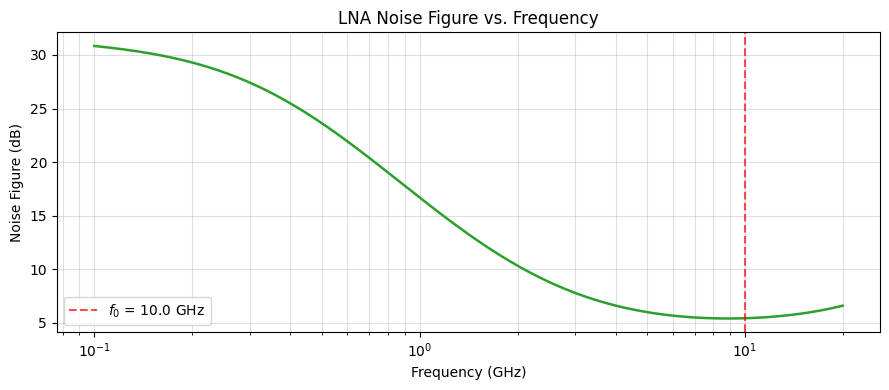

NF @ 10.0 GHz : 5.42 dB
Min NF            : 5.40 dB  @ 8.913 GHz


In [1696]:
import scipy.constants as const

T0 = 290    # IEEE standard reference temperature (K)
Rs = 50     # source resistance (Ω)

d = noise_data["data"]
freq_n = np.abs(d.get("frequency", np.array([])))

# ngspice noise variable names (case-insensitive search)
def find_key(data, *candidates):
    for k in data:
        if k.lower() in [c.lower() for c in candidates]:
            return data[k]
    return None

onoise = find_key(d, "onoise_spectrum")  # V²/Hz
inoise = find_key(d, "inoise_spectrum")  # V²/Hz  (input-referred)

if onoise is None:
    print("Could not find 'onoise_spectrum' in noise data. Keys:", list(d.keys()))
else:
    onoise = np.abs(onoise.real)   # take real part (should be positive)

Av = np.abs(ac_data["data"]["v(vout)"] / ac_data["data"]["v(vin)"])

# interpolate gain onto noise frequencies
Av_f = np.interp(freq_n, freq_ac, Av)

# Razavi equation
NF_lin = onoise / (4 * const.k * T0 * Rs * Av_f**2)
NF = 10 * np.log10(NF_lin)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(freq_n / 1e9, NF, "C2", linewidth=1.8)
ax.axvline(FREQUENCY / 1e9, color="r", linestyle="--", alpha=0.7,
						label=f"$f_0$ = {FREQUENCY/1e9:.1f} GHz")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Noise Figure (dB)")
ax.set_title("LNA Noise Figure vs. Frequency")
ax.grid(which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(".out/noise_figure.png", dpi=150, bbox_inches="tight")
plt.show()

# --- print value at operating frequency ---
idx_f0 = np.argmin(np.abs(freq_n - FREQUENCY))
print(f"NF @ {FREQUENCY/1e9:.1f} GHz : {NF[idx_f0]:.2f} dB")
print(f"Min NF            : {NF.min():.2f} dB  @ {freq_n[NF.argmin()]/1e9:.3f} GHz")


#### S-Parameter extraction
In order to obtain the corresponding S-Parameters for the LNA, we need to change the netlist a little bit. First, we remove the series resistor from the input and declare `Vin` as `portnum 1` with `z0 50`. This marks the voltage source as the input port with an intrinsic impedance of $50\,\Omega$. Also, we add an output port `Vout` which will be `portnum 2` and will also have `z0 50`.

In [1697]:
circ_title = f".title LNA {FREQUENCY/1e9} GHz (RF)"
netlist = f"""
** VDD source
VDD VDD 0 {VDD}
** Bias branch
IREF VDD G1 {I_REF/1e-6:.3f}u
CB G1 0 1p
XMB G1 G1 0 0 sg13_lv_nmos w={WB:.3f}u l={L1:.3f}u ng={nfB} m=1 rfmode=1
** Input source and capacitance
Vin S1 0 DC 0 AC 1 portnum 1 z0 50
Cpad S1 0 {C_IN/1e-15}f
** Input resonance tank
Rp2 S1 0 {sol_value(sol_in, R_p).to("kohm").magnitude:.3f}k
Ls2 S1 net1 {sol_value(sol_in, L).to("nH").magnitude:.3f}n
Rs2 net1 0 {sol_value(sol_in, R_s).to("ohm").magnitude:.3f}
Ctot2 S1 0 {sol_value(sol_in, C_p + C_s).to("fF").magnitude:.3f}f
** Cascoded CG amplifier
XM1 X G1 S1 0 sg13_lv_nmos w={W1:.3f}u l={L1:.3f}u ng={nf1} m=1 rfmode=1
XM2 VOUT VDD X 0 sg13_lv_nmos w={W1:.3f}u l={L1:.3f}u ng={nf1} m=1 rfmode=1
** Output resonance tank
Rp1 VDD VOUT {sol_value(sol_out, R_p).to("kohm").magnitude:.3f}k
Ls1 VDD net2 {sol_value(sol_out, L).to("nH").magnitude:.3f}n
Rs1 net2 VOUT {sol_value(sol_out, R_s).to("ohm").magnitude:.3f}
Ctot1 VDD VOUT {sol_value(sol_out, C_p + C_s).to("fF").magnitude:.3f}f
** Output port and capacitance
Vout VOUT 0 DC 0 AC 0 portnum 2 z0 50
Cpad2 VOUT 0 {C_OUT/1e-15}f
"""

In [1698]:
control_block = f"""
.control
save all
* --- S-Parameters ---
sp dec 100 100e6 20e9
write .out/CG_LNA_{FREQUENCY/1e9}GHz_RF.raw
.endc
"""

In [1699]:
with open(f".out/CG_LNA_{FREQUENCY/1e9}GHz_RF.spice", "w") as f:
  f.write(circ_title)
  f.write(lib_includes)
  f.write(netlist)
  f.write(control_block)
  
freq = str(FREQUENCY/1e9)
!ngspice -b {'.out/CG_LNA_' + freq + 'GHz_RF.spice'} >> /dev/null

Note: Starting dynamic gmin stepping
Note: Dynamic gmin stepping completed


In [1700]:
analyses = parse_ngspice_raw(f'.out/CG_LNA_{FREQUENCY/1e9}GHz_RF.raw')

sp_data   = None   # S-parameters

for a in analyses:
   pn = a["plotname"].lower()
   if "s-parameter" in pn or "s parameter" in pn or "sp analysis" in pn:
      sp_data = a

print(f"Found {len(analyses)} analysis block(s):")
for a in analyses:
   print(f"  plotname='{a['plotname']}',  "
        f"vars={len(a['variables'])},  "
        f"points={len(next(iter(a['data'].values())))}")

Found 1 analysis block(s):
  plotname='SP Analysis',  vars=156,  points=231


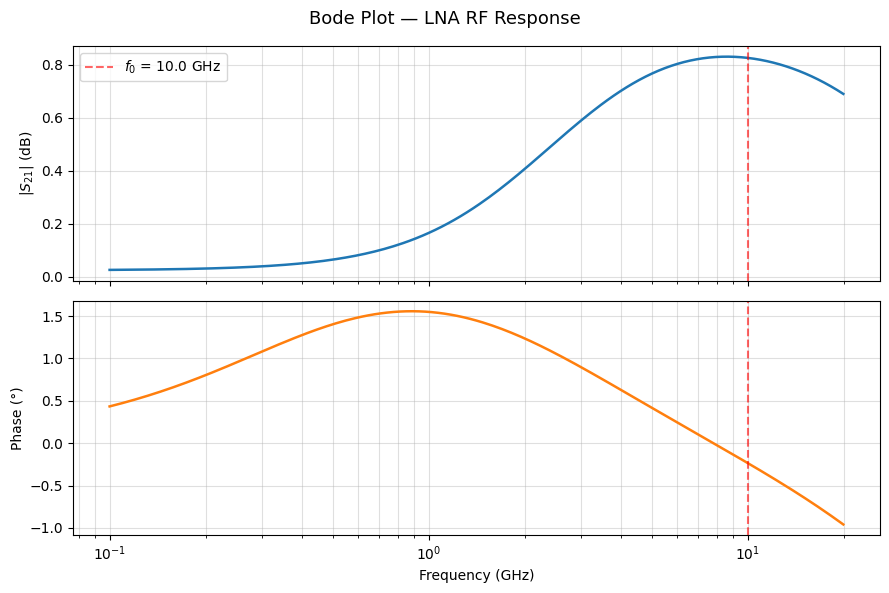

Peak gain : 0.83 dB  @ 8.511 GHz
Gain @ f0 : 0.83 dB


In [1701]:
freq     = np.abs(sp_data["data"]["frequency"])   # Hz

d = sp_data["data"]
S11 = get_s(d, 1, 1);  S12 = get_s(d, 1, 2)
S21 = get_s(d, 2, 1);  S22 = get_s(d, 2, 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle("Bode Plot — LNA RF Response", fontsize=13)
# --- magnitude ---
ax1.semilogx(freq / 1e9, np.abs(S21), "C0", linewidth=1.8)
ax1.axvline(FREQUENCY / 1e9, color="r", linestyle="--", alpha=0.6,
						label=f"$f_0$ = {FREQUENCY/1e9:.1f} GHz")
ax1.set_ylabel("$|S_{21}|$ (dB)")
ax1.grid(which="both", alpha=0.4)
ax1.legend()

# --- phase ---
ax2.semilogx(freq / 1e9, np.angle(S21), "C1", linewidth=1.8)
ax2.axvline(FREQUENCY / 1e9, color="r", linestyle="--", alpha=0.6)
ax2.set_ylabel("Phase (°)")
ax2.set_xlabel("Frequency (GHz)")
ax2.grid(which="both", alpha=0.4)

plt.tight_layout()
plt.savefig(".out/bode_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# --- print peak gain ---
idx_peak = np.argmax(np.abs(S21))
print(f"Peak gain : {np.abs(S21[idx_peak]):.2f} dB  "
			f"@ {freq[idx_peak]/1e9:.3f} GHz")
idx_f0 = np.argmin(np.abs(freq - FREQUENCY))
print(f"Gain @ f0 : {np.abs(S21[idx_f0]):.2f} dB")

In [1702]:
def stability_circles_from_S(S11, S12, S21, S22):
   """Return (C_S, r_S, C_L, r_L) for each frequency point."""
   Delta = S11 * S22 - S12 * S21

   denom_S = np.abs(S11)**2 - np.abs(Delta)**2
   C_S    = np.conj(S11 - Delta * np.conj(S22)) / denom_S
   r_S    = np.abs(S12 * S21 / denom_S)

   denom_L = np.abs(S22)**2 - np.abs(Delta)**2
   C_L    = np.conj(S22 - Delta * np.conj(S11)) / denom_L
   r_L    = np.abs(S12 * S21 / denom_L)

   return C_S, r_S, C_L, r_L


def rollett_K(S11, S12, S21, S22):
   Delta = S11 * S22 - S12 * S21
   return (1 - np.abs(S11)**2 - np.abs(S22)**2 + np.abs(Delta)**2) \
         / (2 * np.abs(S12 * S21))


def draw_smith_chart(ax):
   """Draw a minimal Smith-chart grid on *ax*."""
   theta = np.linspace(0, 2 * np.pi, 400)
   # unit circle
   ax.plot(np.cos(theta), np.sin(theta), "k", lw=0.8)
   ax.plot([-1, 1], [0, 0], "k", lw=0.5)
   # constant-resistance circles: r = 0, 0.5, 1, 2
   for r in [0, 0.5, 1, 2]:
      cx, rad = r / (1 + r), 1 / (1 + r)
      ax.plot(cx + rad * np.cos(theta), rad * np.sin(theta),
            "gray", lw=0.4, alpha=0.6)
   # constant-reactance arcs: x = ±0.5, ±1, ±2
   for x in [0.5, 1, 2]:
      cy, rad = 1 / x, 1 / x
      phi = np.linspace(-np.pi / 2, 3 * np.pi / 2, 400)
      xs, ys = 1 + rad * np.cos(phi), cy + rad * np.sin(phi)
      inside = xs**2 + ys**2 <= 1.01
      ax.plot(xs[inside],  ys[inside],  "gray", lw=0.4, alpha=0.6)
      ax.plot(xs[inside], -ys[inside],  "gray", lw=0.4, alpha=0.6)
   ax.set_aspect("equal")
   ax.set_xlim(-1.3, 1.3)
   ax.set_ylim(-1.3, 1.3)
   ax.axis("off")


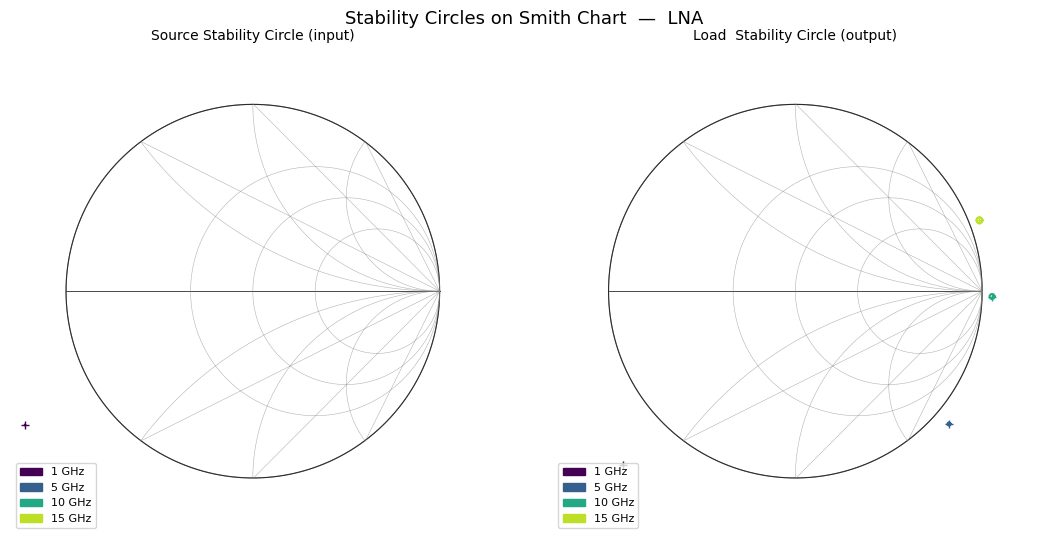


Rollett stability factor K @ 10.0 GHz : 4.125
LNA appears unconditionally stable at f0.


In [1703]:
C_S, r_S, C_L, r_L = stability_circles_from_S(S11, S12, S21, S22)
K = rollett_K(S11, S12, S21, S22)

# --- pick a subset of frequencies to draw circles ---
f_GHz   = freq / 1e9
f_marks = [1, 5, 10, 15, 20]  # GHz
idxs   = [np.argmin(np.abs(f_GHz - f)) for f in f_marks
						if f_GHz.min() <= f <= f_GHz.max()]
colors  = plt.cm.viridis(np.linspace(0, 0.9, len(idxs)))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
fig.suptitle("Stability Circles on Smith Chart  —  LNA", fontsize=13)

for ax, (C_arr, r_arr, title) in zip(
		axes,
		[(C_S, r_S, "Source Stability Circle (input)"),
			(C_L, r_L, "Load  Stability Circle (output)")]
):
		draw_smith_chart(ax)
		ax.set_title(title, fontsize=10)

		theta = np.linspace(0, 2 * np.pi, 300)
		handles = []
		for i, idx in enumerate(idxs):
				cx, cy = C_arr[idx].real, C_arr[idx].imag
				r     = r_arr[idx]
				circle_x = cx + r * np.cos(theta)
				circle_y = cy + r * np.sin(theta)
				line,  = ax.plot(circle_x, circle_y, color=colors[i], lw=1.5)
				ax.plot(cx, cy, "+", color=colors[i], ms=6)
				handles.append(mpatches.Patch(
						color=colors[i], label=f"{f_GHz[idx]:.0f} GHz"))

		ax.legend(handles=handles, fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

# --- Rollett factor at f0 ---
idx_f0 = np.argmin(np.abs(freq - FREQUENCY))
K_f0   = K[idx_f0].real
print(f"\nRollett stability factor K @ {FREQUENCY/1e9:.1f} GHz : {K_f0:.3f}")
if K_f0 > 1 and np.abs(S11[idx_f0])**2 - np.abs(S11[idx_f0]*S22[idx_f0]
													- S12[idx_f0]*S21[idx_f0])**2 < 1:
		print("LNA appears unconditionally stable at f0.")
else:
		print("Potentially conditionally stable at f0 — verify with full SP sim.")
